In [40]:
import geopandas as gpd
import pandas as pd
import numpy as np
import datetime as dt
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap
import os

In [41]:
def scale_bar(ax, length=None, location=(0.5, 0.05), linewidth=3):
    """
    ax is the axes to draw the scalebar on.
    length is the length of the scalebar in km.
    location is center of the scalebar in axis coordinates.
    (ie. 0.5 is the middle of the plot)
    linewidth is the thickness of the scalebar.
    """
    #Get the limits of the axis in lat long
    llx0, llx1, lly0, lly1 = ax.get_extent(ccrs.PlateCarree())
    #Make tmc horizontally centred on the middle of the map,
    #vertically at scale bar location
    sbllx = (llx1 + llx0) / 2
    sblly = lly0 + (lly1 - lly0) * location[1]
    tmc = ccrs.TransverseMercator(sbllx, sblly)
    #Get the extent of the plotted area in coordinates in metres
    x0, x1, y0, y1 = ax.get_extent(tmc)
    #Turn the specified scalebar location into coordinates in metres
    sbx = x0 + (x1 - x0) * location[0]
    sby = y0 + (y1 - y0) * location[1]

    #Calculate a scale bar length if none has been given
    #(Theres probably a more pythonic way of rounding the number but this works)
    if not length: 
        length = (x1 - x0) / 5000 #in km
        ndim = int(np.floor(np.log10(length))) #number of digits in number
        length = round(length, -ndim) #round to 1sf
        #Returns numbers starting with the list
        def scale_number(x):
            if str(x)[0] in ['1', '2', '5']: return int(x)        
            else: return scale_number(x - 10 ** ndim)
        length = scale_number(length) 

    #Generate the x coordinate for the ends of the scalebar
    bar_xs = [sbx - length * 500, sbx + length * 500]
    #Plot the scalebar
    ax.plot(bar_xs, [sby, sby], transform=tmc, color='k', linewidth=linewidth)
    #Plot the scalebar label
    ax.text(sbx, sby, str(length) + ' km', transform=tmc,
            horizontalalignment='center', verticalalignment='bottom', fontsize=10)

<h3>Creek Fire

In [42]:
dets_all = pd.read_csv('/projects/shared-buckets/coffield/WUS_Jun-Nov2020_dets_SNPP_clipped.csv')

#dets.acq_date = pd.to_datetime(dets.acq_date)
dets_all.acq_time = dets_all.acq_time.astype(str).str.zfill(4)
dets_all['datetime'] = dets_all.acq_date.astype(str) + dets_all.acq_time
dets_all['datetime'] = pd.to_datetime(dets_all.datetime, format='%m/%d/%y%H%M')

dets = dets_all[dets_all.Incid_Name=='CREEK']
dets

,longitude,latitude,fire_mask,daynight,confidence,acq_date,acq_time,j,i750,j750,frp_old,frp,dist_m13b,fireid,Incid_Name,datetime
106644,-119.089840,37.353027,8,D,n,6/14/20,2036,4017,1566,2008,2.459210,2.459210,NaN,F12649,CREEK,2020-06-14 20:36:00
106645,-119.087890,37.354736,5,D,x,6/14/20,2036,4015,1568,2007,NaN,2.565132,0.002720,F12649,CREEK,2020-06-14 20:36:00
106646,-119.088870,37.349426,8,N,n,6/15/20,0854,779,2693,389,1.277629,1.277629,NaN,F12649,CREEK,2020-06-15 08:54:00
106647,-119.088870,37.351013,8,N,n,6/18/20,0942,2924,586,1462,0.647789,0.647789,NaN,F12649,CREEK,2020-06-18 09:42:00
106648,-119.087890,37.348633,9,D,h,6/18/20,2100,2678,2137,1339,22.385473,22.385473,NaN,F12649,CREEK,2020-06-18 21:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
156273,-119.276370,37.611330,6,N,x,11/6/20,1036,5632,1973,2816,NaN,-0.645337,1.524952,F12649,CREEK,2020-11-06 10:36:00
156274,-118.988280,37.412660,6,N,x,11/7/20,1018,4817,1606,2408,NaN,1.574404,1.201568,F12649,CREEK,2020-11-07 10:18:00
156275,-119.321290,37.113280,5,D,x,11/15/20,2048,3429,1958,1714,NaN,1.927158,0.994679,F12649,CREEK,2020-11-15 20:48:00
156276,-119.384766,37.430420,8,D,n,11/27/20,2024,4624,1355,2312,9.907524,9.907524,NaN,F12649,CREEK,2020-11-27 20:24:00


In [43]:
#nirops - all (processed by Tina Liu)
#these contain cumulative polygons for each variable, with timestamps
intense = gpd.read_file('/projects/shared-buckets/coffield/nirops/processed/Creek_2020_intenseHeat.shp')
intense.flight_UTC = pd.to_datetime(intense.flight_UTC)
intense.head()

,prodDate,flightDate,flightTime,flight_tz,flight_UTC,DT_QA,DT_source,garea_km2,geometry
0,20200906.0,20200906.0,500.0,UTC,2020-09-06 05:00:00,0.0,doc,17.870951,"MULTIPOLYGON (((-119.36845 37.33453, -119.3682..."
1,20200908.0,20200908.0,730.0,UTC,2020-09-08 07:30:00,0.0,doc,115.414706,"MULTIPOLYGON (((-119.19162 37.13643, -119.1916..."
2,20200909.0,20200909.0,530.0,UTC,2020-09-09 05:30:00,0.0,doc,151.294591,"MULTIPOLYGON (((-119.15120 37.21895, -119.1516..."
3,20200910.0,20200910.0,745.0,UTC,2020-09-10 07:45:00,0.0,doc,169.929383,"MULTIPOLYGON (((-119.38822 37.04442, -119.3881..."
4,20200912.0,20200912.0,615.0,UTC,2020-09-12 06:15:00,0.0,doc,188.442714,"MULTIPOLYGON (((-119.17067 37.26099, -119.1721..."


In [45]:
isolated = gpd.read_file('/projects/shared-buckets/coffield/nirops/processed/Creek_2020_isolatedHeat.shp')
isolated.flight_UTC = pd.to_datetime(isolated.flight_UTC)

scattered = gpd.read_file('/projects/shared-buckets/coffield/nirops/processed/Creek_2020_scatteredHeat.shp')
scattered.flight_UTC = pd.to_datetime(scattered.flight_UTC)

fire_lines = gpd.read_file('/projects/shared-buckets/coffield/nirops/processed/Creek_2020_fireLines.shp')
fire_lines.flight_UTC = pd.to_datetime(fire_lines.flight_UTC)
fire_lines.iloc[45:46,:]

,prodDate,flightDate,flightTime,flight_tz,flight_UTC,DT_QA,DT_source,heatType,length_km,length_per,geometry
45,20201102.0,20201101.0,2315.0,UTC,2020-11-01 23:15:00,0.0,doc,intense,295.413533,0.390626,"MULTILINESTRING ((-119.09132 37.45650, -119.09..."


In [46]:
np.unique(fire_lines.heatType)

array(['combined', 'intense', 'scattered'], dtype=object)

In [47]:
#loop through nirops and count how many matches to VIIRS within 2 hours
matches = []
file_dates = []

for i in intense.index:
    datetime = intense.loc[i, 'flight_UTC']
    subset = dets[np.abs(dets.datetime - datetime) < dt.timedelta(hours=2)]
    
    if len(subset)>0:
        print(f'match at flight time: {datetime} UTC\n VIIRS time: {np.unique(subset.datetime)} UTC\n')
        matches.append(datetime)
        file_dates.append(int(intense.loc[i, 'flightDate']))

match at flight time: 2020-09-08 07:30:00 UTC
 VIIRS time: ['2020-09-08T09:00:00.000000000' '2020-09-08T09:06:00.000000000'] UTC

match at flight time: 2020-10-11 06:45:00 UTC
 VIIRS time: ['2020-10-11T08:42:00.000000000'] UTC

match at flight time: 2020-11-01 23:15:00 UTC
 VIIRS time: ['2020-11-01T21:54:00.000000000'] UTC

match at flight time: 2020-11-03 22:00:00 UTC
 VIIRS time: ['2020-11-03T21:12:00.000000000'] UTC



In [48]:
matches, file_dates

([Timestamp('2020-09-08 07:30:00'),
  Timestamp('2020-10-11 06:45:00'),
  Timestamp('2020-11-01 23:15:00'),
  Timestamp('2020-11-03 22:00:00')],
 [20200908, 20201011, 20201101, 20201103])

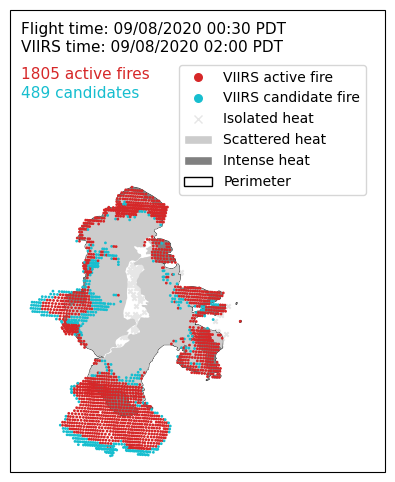

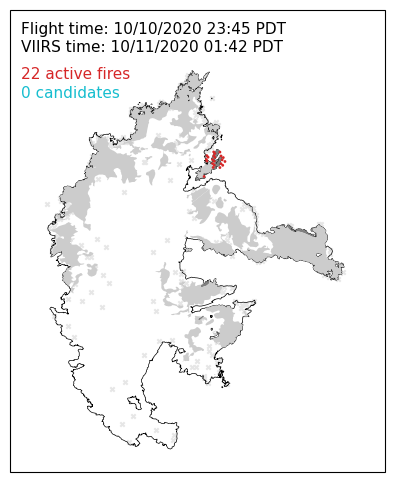

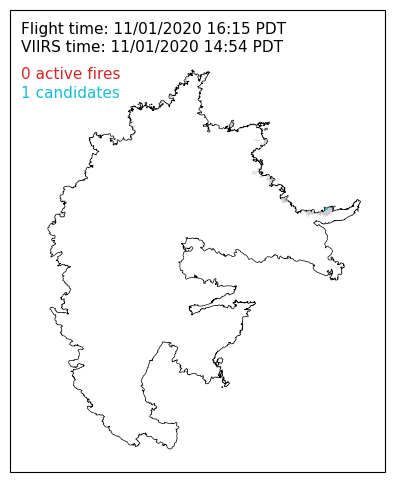

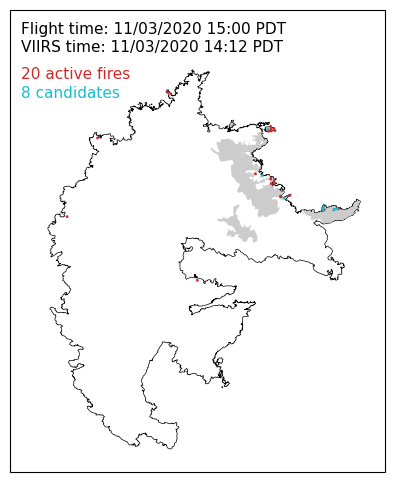

In [69]:
#map figure

newcolors = [mpl.colormaps['tab10'](c) for c in [9,9,9,9,9,9,9,3,3,3]] #just old vs new dets
newcmp = ListedColormap(newcolors)
extent = [-119.55,-118.9,36.95,37.75] #creek

crs = ccrs.PlateCarree()
crs_proj4 = crs.proj4_init

#legend
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_elements = [Line2D([0], [0], marker='.', color='w', label='VIIRS active fire', markerfacecolor=newcmp(7), markersize=15),
                   Line2D([0], [0], marker='.', color='w', label='VIIRS candidate fire', markerfacecolor=newcmp(0), markersize=15),
                   Line2D([0], [0], marker='x', color='0.9', label='Isolated heat', markersize=6, linestyle=''),
                   Patch(facecolor='0.8', edgecolor='w', label='Scattered heat'),
                   Patch(facecolor='0.5', edgecolor='w', label='Intense heat'),
                   Patch(facecolor='none', edgecolor='k', label='Perimeter'),
                  ]
    
for d, file_date in zip(matches, file_dates):

    subset = dets[np.abs(dets.datetime - d) < dt.timedelta(hours=2)]
    files = os.listdir('/projects/shared-buckets/coffield/nirops/raw/Creek/')
    files = [f for f in files if f[:8] == str(file_date)]
    files = [f for f in files if f[-3:] == 'shp']

    fig, ax = plt.subplots(1,1, figsize=(6,6), subplot_kw={"projection": crs})
    ax.set_extent(extent)

    ax.scatter(subset['longitude'], subset['latitude'], c=newcmp(subset['fire_mask'].astype(int)), s=1, zorder=100, transform=ccrs.Geodetic())

    perim = [f for f in files if 'Perimeter' in f][0]
    perim = gpd.read_file(f'/projects/shared-buckets/coffield/nirops/raw/Creek/{perim}')
    perim_reproj = perim.to_crs(crs_proj4)
    ax.add_geometries(perim_reproj.dissolve().buffer(0.0001).geometry, crs=crs, facecolor='none', edgecolor='k', linewidth=0.5)
    #^added a dissolve and tiny buffer to remove stray line segments
    
    inten = [f for f in files if 'Intense' in f][0]
    inten = gpd.read_file(f'/projects/shared-buckets/coffield/nirops/raw/Creek/{inten}')
    inten_reproj = inten.to_crs(crs_proj4)
    ax.add_geometries(inten_reproj.geometry, crs=crs, facecolor='0.5')

    isola = [f for f in files if 'Isolated' in f][0]
    isola = gpd.read_file(f'/projects/shared-buckets/coffield/nirops/raw/Creek/{isola}')
    ax.scatter(isola.geometry.x, isola.geometry.y, transform=ccrs.Geodetic(), color='0.9', s=10, marker='x', label='Isolated Heat')

    scatt = [f for f in files if 'Scattered' in f][0]
    scatt = gpd.read_file(f'/projects/shared-buckets/coffield/nirops/raw/Creek/{scatt}')
    scatt_reproj = scatt.to_crs(crs_proj4)
    ax.add_geometries(scatt_reproj.geometry, crs=crs, facecolor='0.8')

    if file_date==20200908: ax.legend(handles=legend_elements, loc=(0.45,0.6))

    flight_time = (d - dt.timedelta(hours=7)).strftime("%m/%d/%Y %H:%M")
    #viirs_time = subset.loc[pd.to_datetime(str(t)).strftime("%m/%d/%Y %H:%M") for t in np.unique(subset.datetime)]
    viirs_time = (subset.datetime.iloc[0] - dt.timedelta(hours=7)).strftime("%m/%d/%Y %H:%M")
    ax.annotate(f'Flight time: {flight_time} PDT\nVIIRS time: {viirs_time} PDT', xy=(0.03, 0.91), size=11, xycoords=ax.transAxes)
    
    n_known = len(subset[subset.fire_mask>6])
    n_candi = len(subset[subset.fire_mask<7])
    ax.annotate(f'{n_known} active fires', xy=(0.03, 0.85), color=newcmp(7), size=11, xycoords=ax.transAxes)
    ax.annotate(f'{n_candi} candidates', xy=(0.03, 0.81), color=newcmp(0), size=11, xycoords=ax.transAxes)

    plt.savefig(f'/projects/my-public-bucket/figures/nirops_creek_{file_date}', bbox_inches='tight', dpi=125)

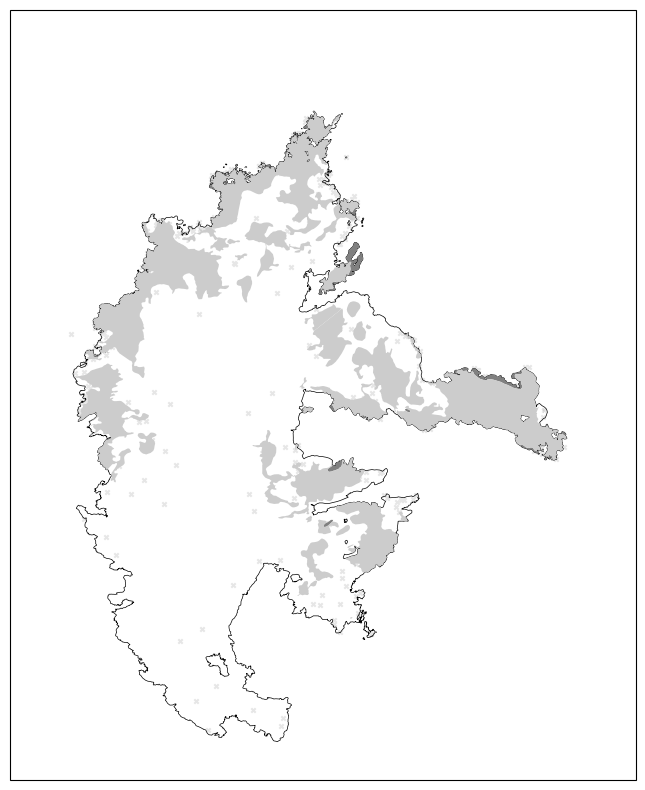

In [67]:
file_date = 20201011

files = os.listdir('/projects/shared-buckets/coffield/nirops/raw/Creek/')
files = [f for f in files if f[:8] == str(file_date)]
files = [f for f in files if f[-3:] == 'shp']

fig, ax = plt.subplots(1,1, figsize=(10,10), subplot_kw={"projection": crs})
ax.set_extent(extent)

perim = [f for f in files if 'Perimeter' in f][0]
perim = gpd.read_file(f'/projects/shared-buckets/coffield/nirops/raw/Creek/{perim}')
perim_reproj = perim.to_crs(crs_proj4)
ax.add_geometries(perim_reproj.dissolve().buffer(0.0001).geometry, crs=crs, facecolor='none', edgecolor='k', linewidth=0.5)

inten = [f for f in files if 'Intense' in f][0]
inten = gpd.read_file(f'/projects/shared-buckets/coffield/nirops/raw/Creek/{inten}')
inten_reproj = inten.to_crs(crs_proj4)
ax.add_geometries(inten_reproj.geometry, crs=crs, facecolor='0.5')

isola = [f for f in files if 'Isolated' in f][0]
isola = gpd.read_file(f'/projects/shared-buckets/coffield/nirops/raw/Creek/{isola}')
ax.scatter(isola.geometry.x, isola.geometry.y, transform=ccrs.Geodetic(), color='0.9', s=10, marker='x', label='Isolated Heat')

scatt = [f for f in files if 'Scattered' in f][0]
scatt = gpd.read_file(f'/projects/shared-buckets/coffield/nirops/raw/Creek/{scatt}')
scatt_reproj = scatt.to_crs(crs_proj4)
ax.add_geometries(scatt_reproj.geometry, crs=crs, facecolor='0.8')

In [65]:
perim_reproj.dissolve().buffer(0.001).explore()

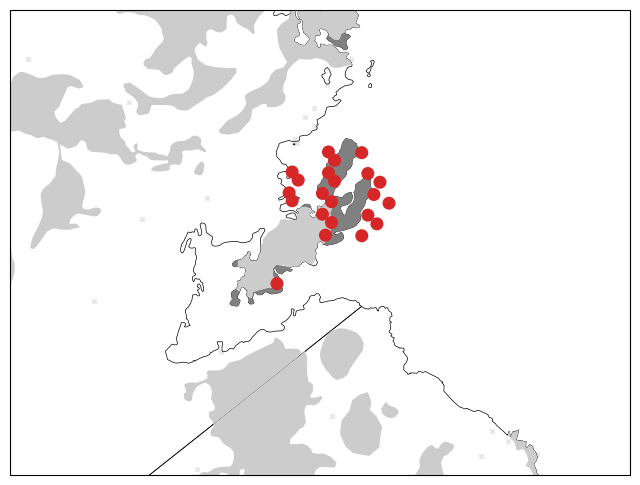

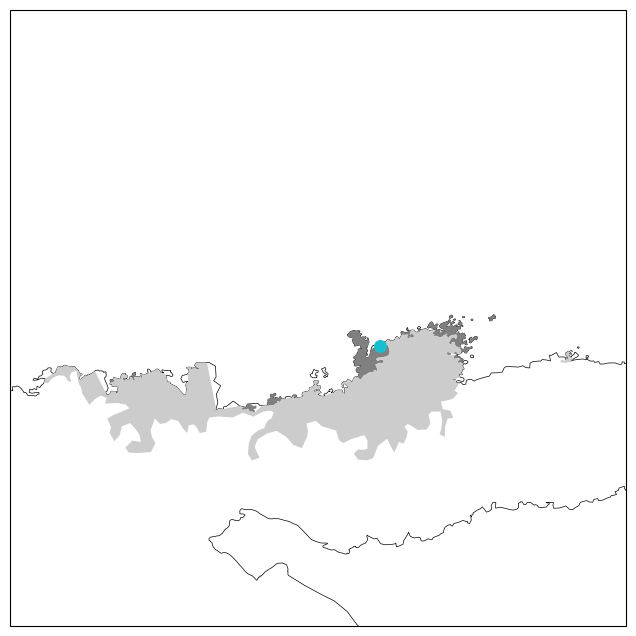

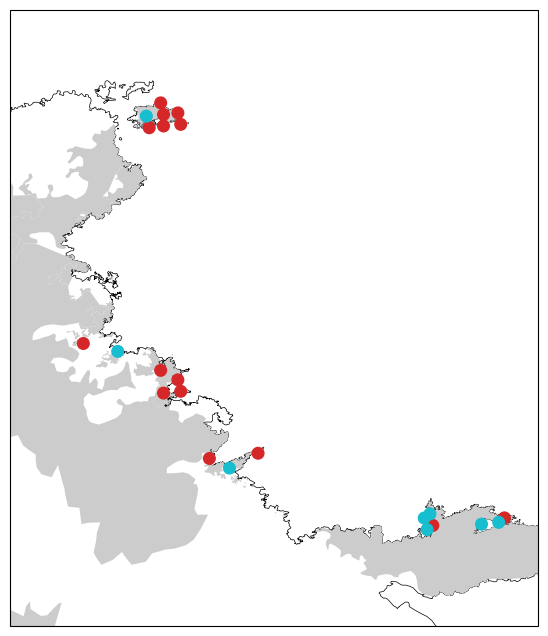

In [83]:
#again, inset for the last 3

for d, file_date in zip(matches, file_dates):

    subset = dets[np.abs(dets.datetime - d) < dt.timedelta(hours=2)]
    files = os.listdir('/projects/shared-buckets/coffield/nirops/raw/Creek/')
    files = [f for f in files if f[:8] == str(file_date)]
    files = [f for f in files if f[-3:] == 'shp']

    if file_date==20200908: continue
    elif file_date==20201011: extent = [-119.3,-119.1,37.4,37.55] #creek zoom inset
    elif file_date==20201101: extent = [-119.05,-118.97,37.37,37.45] #creek zoom inset
    elif file_date==20201103: extent = [-119.15,-118.97,37.37,37.58] #creek zoom inset

    crs = ccrs.PlateCarree()
    crs_proj4 = crs.proj4_init

    fig, ax = plt.subplots(1,1, figsize=(8,8), subplot_kw={"projection": crs})
    ax.set_extent(extent)

    ax.scatter(subset['longitude'], subset['latitude'], c=newcmp(subset['fire_mask'].astype(int)), s=70, zorder=100, transform=ccrs.Geodetic())

    perim = [f for f in files if 'Perimeter' in f][0]
    perim = gpd.read_file(f'/projects/shared-buckets/coffield/nirops/raw/Creek/{perim}')
    perim_reproj = perim.to_crs(crs_proj4)
    ax.add_geometries(perim_reproj.geometry, crs=crs, facecolor='none', edgecolor='k', linewidth=0.5)

    inten = [f for f in files if 'Intense' in f][0]
    inten = gpd.read_file(f'/projects/shared-buckets/coffield/nirops/raw/Creek/{inten}')
    inten_reproj = inten.to_crs(crs_proj4)
    ax.add_geometries(inten_reproj.geometry, crs=crs, facecolor='0.5')

    isola = [f for f in files if 'Isolated' in f][0]
    isola = gpd.read_file(f'/projects/shared-buckets/coffield/nirops/raw/Creek/{isola}')
    ax.scatter(isola.geometry.x, isola.geometry.y, transform=ccrs.Geodetic(), color='0.9', s=10, marker='x', label='Isolated Heat')

    scatt = [f for f in files if 'Scattered' in f][0]
    scatt = gpd.read_file(f'/projects/shared-buckets/coffield/nirops/raw/Creek/{scatt}')
    scatt_reproj = scatt.to_crs(crs_proj4)
    ax.add_geometries(scatt_reproj.geometry, crs=crs, facecolor='0.8')

    plt.savefig(f'/projects/shared-buckets/coffield/figures/nirops_creek_zoom_{file_date}', bbox_inches='tight', dpi=100)

<h3> Other examples - August Complex

In [17]:
fires = gpd.read_file('/projects/shared-buckets/coffield/2020_feds_large_fires_buffered.geojson')  
extent = fires.loc[fires.name=='AUGUST COMPLEX', 'geometry'].bounds
extent

,minx,miny,maxx,maxy
0,-123.54047,39.419284,-122.524037,40.462605


In [18]:
dets = dets_all[dets_all.Incid_Name=='AUGUST COMPLEX']
dets.head()

,longitude,latitude,fire_mask,daynight,confidence,acq_date,acq_time,j,i750,j750,frp_old,frp,dist_m13b,fireid,Incid_Name,datetime
0,-122.536130,39.669617,5,D,x,8/14/20,2136,1734,342,867,NaN,2.810732,0.640692,F11445,AUGUST COMPLEX,2020-08-14 21:36:00
1,-122.556640,39.791810,5,D,x,8/14/20,2136,1733,360,866,NaN,2.147372,0.526319,F11445,AUGUST COMPLEX,2020-08-14 21:36:00
2,-122.674805,39.765137,2,D,x,8/16/20,2054,3606,2675,1803,NaN,2.505991,1.746884,F11445,AUGUST COMPLEX,2020-08-16 20:54:00
3,-122.675780,39.768494,2,D,x,8/16/20,2054,3606,2675,1803,NaN,2.505991,1.746884,F11445,AUGUST COMPLEX,2020-08-16 20:54:00
4,-122.691410,39.774660,8,N,n,8/17/20,0912,959,3114,479,2.454743,2.454743,NaN,F11445,AUGUST COMPLEX,2020-08-17 09:12:00


In [19]:
#nirops - all (processed Tina)
processed = gpd.read_file('/projects/shared-buckets/coffield/nirops/processed/August_Complex_2020_perim.shp')[['prodDate','flightDate','flightTime','flight_tz','flight_UTC']]
processed.flight_UTC = pd.to_datetime(processed.flight_UTC)
processed

,prodDate,flightDate,flightTime,flight_tz,flight_UTC
0,20200820.0,20200820.0,930.0,UTC,2020-08-20 09:30:00
1,20200823.0,20200823.0,400.0,UTC,2020-08-23 04:00:00
2,20200825.0,20200825.0,800.0,UTC,2020-08-25 08:00:00
3,20200828.0,20200828.0,352.0,UTC,2020-08-28 03:52:00
4,20200830.0,20200830.0,659.0,UTC,2020-08-30 06:59:00
...,...,...,...,...,...
62,20201026.0,20201026.0,310.0,UTC,2020-10-26 03:10:00
63,20201027.0,20201027.0,545.0,UTC,2020-10-27 05:45:00
64,20201029.0,20201029.0,220.0,UTC,2020-10-29 02:20:00
65,20201101.0,20201101.0,350.0,UTC,2020-11-01 03:50:00


In [20]:
#loop through nirops and count how many matches to VIIRS within 2 hours
matches = []
file_dates = []

for i in processed.index:
    datetime = processed.loc[i, 'flight_UTC']
    subset = dets[np.abs(dets.datetime - datetime) < dt.timedelta(hours=2)]
    
    if len(subset)>0:
        print(f'match at flight time: {datetime} UTC\n VIIRS time: {np.unique(subset.datetime)} UTC\n')
        matches.append(datetime)
        file_dates.append(int(processed.loc[i, 'flightDate']))

match at flight time: 2020-08-20 09:30:00 UTC
 VIIRS time: ['2020-08-20T10:00:00.000000000'] UTC

match at flight time: 2020-09-12 07:45:00 UTC
 VIIRS time: ['2020-09-12T09:30:00.000000000'] UTC

match at flight time: 2020-09-12 07:45:00 UTC
 VIIRS time: ['2020-09-12T09:30:00.000000000'] UTC

match at flight time: 2020-09-12 07:45:00 UTC
 VIIRS time: ['2020-09-12T09:30:00.000000000'] UTC

match at flight time: 2020-09-12 07:45:00 UTC
 VIIRS time: ['2020-09-12T09:30:00.000000000'] UTC

match at flight time: 2020-09-17 08:00:00 UTC
 VIIRS time: ['2020-09-17T09:36:00.000000000'] UTC

match at flight time: 2020-10-04 07:30:00 UTC
 VIIRS time: ['2020-10-04T09:12:00.000000000'] UTC



In [21]:
matches = np.unique(matches) #removing duplicates
file_dates = np.unique(file_dates)
matches, file_dates

(array([Timestamp('2020-08-20 09:30:00'), Timestamp('2020-09-12 07:45:00'),
        Timestamp('2020-09-17 08:00:00'), Timestamp('2020-10-04 07:30:00')],
       dtype=object),
 array([20200820, 20200912, 20200917, 20201004]))

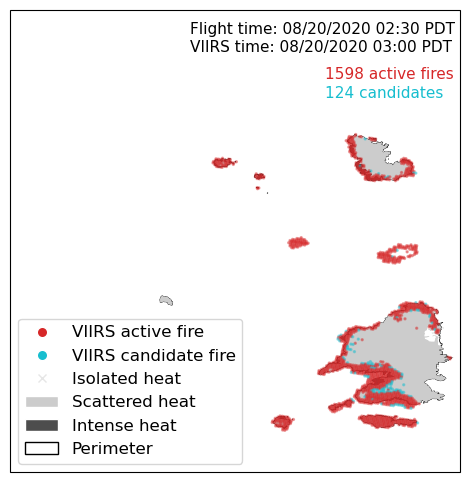

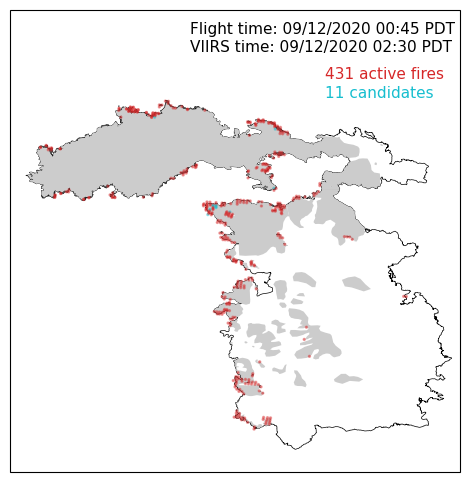

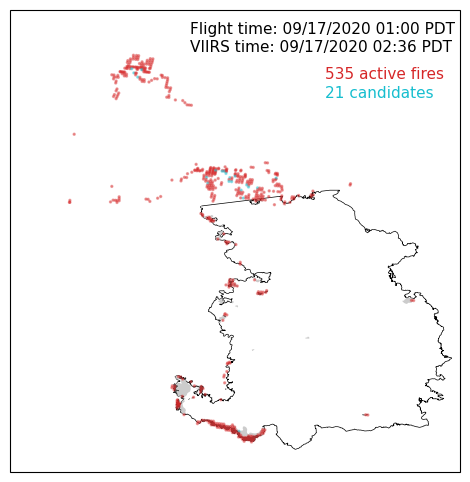

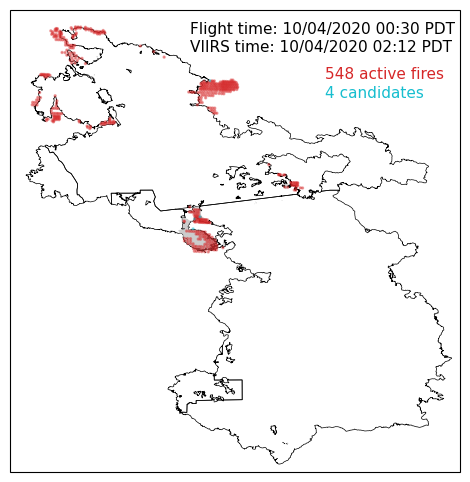

In [24]:
for d, file_date in zip(matches, file_dates):

    subset = dets[np.abs(dets.datetime - d) < dt.timedelta(hours=2)]
    files = os.listdir('/projects/shared-buckets/coffield/nirops/raw/August Complex/')
    files = [f for f in files if f[:8] == str(file_date)]
    files = [f for f in files if f[-3:] == 'shp']

    newcolors = [mpl.colormaps['tab10'](c) for c in [9,9,9,9,9,9,9,3,3,3]] #just old vs new dets
    newcmp = ListedColormap(newcolors)

    crs = ccrs.PlateCarree()
    crs_proj4 = crs.proj4_init

    fig, ax = plt.subplots(1,1, figsize=(6,6), subplot_kw={"projection": crs})
    ax.set_extent([extent.minx, extent.maxx, extent.miny, extent.maxy])

    ax.scatter(subset['longitude'], subset['latitude'], c=newcmp(subset['fire_mask'].astype(int)), s=2, zorder=100, alpha=0.4, transform=ccrs.Geodetic())

    perims = [f for f in files if 'Perimeter' in f] #sometimes multiple pieces
    for perim in perims:
        perim = gpd.read_file(f'/projects/shared-buckets/coffield/nirops/raw/August Complex/{perim}')
        perim_reproj = perim.to_crs(crs_proj4)
        ax.add_geometries(perim_reproj.geometry, crs=crs, facecolor='none', edgecolor='k', linewidth=0.5)

    intens = [f for f in files if 'Intense' in f]
    for inten in intens:
        inten = gpd.read_file(f'/projects/shared-buckets/coffield/nirops/raw/August Complex/{inten}')
        inten_reproj = inten.to_crs(crs_proj4)
        ax.add_geometries(inten_reproj.geometry, crs=crs, facecolor='0.3')

    isolas = [f for f in files if 'Isolated' in f]
    for isola in isolas:
        isola = gpd.read_file(f'/projects/shared-buckets/coffield/nirops/raw/August Complex/{isola}')
        ax.scatter(isola.geometry.x, isola.geometry.y, transform=ccrs.Geodetic(), color='0.9', s=10, marker='x', label='Isolated Heat')

    scatts = [f for f in files if 'Scattered' in f]
    for scatt in scatts:
        scatt = gpd.read_file(f'/projects/shared-buckets/coffield/nirops/raw/August Complex/{scatt}')
        scatt_reproj = scatt.to_crs(crs_proj4)
        ax.add_geometries(scatt_reproj.geometry, crs=crs, facecolor='0.8')

    #legend
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch

    legend_elements = [Line2D([0], [0], marker='.', color='w', label='VIIRS active fire', markerfacecolor=newcmp(7), markersize=15),
                       Line2D([0], [0], marker='.', color='w', label='VIIRS candidate fire', markerfacecolor=newcmp(0), markersize=15),
                       Line2D([0], [0], marker='x', color='0.9', label='Isolated heat', markersize=6, linestyle=''),
                       Patch(facecolor='0.8', edgecolor='w', label='Scattered heat'),
                       Patch(facecolor='0.3', edgecolor='w', label='Intense heat'),
                       Patch(facecolor='none', edgecolor='k', label='Perimeter'),
                      ]
    if file_date==20200820:
        ax.legend(handles=legend_elements, loc='lower left', fontsize=12)

    flight_time = (d - dt.timedelta(hours=7)).strftime("%m/%d/%Y %H:%M")
    #viirs_time = subset.loc[pd.to_datetime(str(t)).strftime("%m/%d/%Y %H:%M") for t in np.unique(subset.datetime)]
    viirs_time = (subset.datetime.iloc[0] - dt.timedelta(hours=7)).strftime("%m/%d/%Y %H:%M")
    ax.annotate(f'Flight time: {flight_time} PDT\nVIIRS time: {viirs_time} PDT', xy=(0.4, 0.91), size=11, xycoords=ax.transAxes)
    
    n_known = len(subset[subset.fire_mask>6])
    n_candi = len(subset[subset.fire_mask<7])
    ax.annotate(f'{n_known} active fires', xy=(0.7, 0.85), color=newcmp(7), size=11, xycoords=ax.transAxes)
    ax.annotate(f'{n_candi} candidates', xy=(0.7, 0.81), color=newcmp(0), size=11, xycoords=ax.transAxes)

    plt.savefig(f'/projects/my-public-bucket/figures/nirops_august-complex_{file_date}', bbox_inches='tight', dpi=125)

<h3>Bobcat

In [25]:
extent = fires.loc[fires.name=='BOBCAT', 'geometry'].bounds
extent

,minx,miny,maxx,maxy
18,-118.125406,34.14262,-117.741075,34.502915


In [26]:
dets = dets_all[dets_all.Incid_Name=='BOBCAT']
dets.head()

,longitude,latitude,fire_mask,daynight,confidence,acq_date,acq_time,j,i750,j750,frp_old,frp,dist_m13b,fireid,Incid_Name,datetime
328659,-118.022460,34.479797,2,D,x,6/19/20,2042,3688,1242,1844,NaN,3.017794,1.534176,F12731,BOBCAT,2020-06-19 20:42:00
328660,-117.918945,34.185240,8,D,n,8/14/20,1954,6061,375,3030,19.359163,19.359163,NaN,F12731,BOBCAT,2020-08-14 19:54:00
328661,-117.925780,34.183290,8,D,n,8/14/20,1954,6062,375,3031,8.972962,8.972962,NaN,F12731,BOBCAT,2020-08-14 19:54:00
328662,-117.920900,34.191650,9,D,h,8/14/20,1954,6061,376,3030,29.552031,29.552031,NaN,F12731,BOBCAT,2020-08-14 19:54:00
328663,-117.927734,34.189636,8,D,n,8/14/20,1954,6062,376,3031,23.927280,23.927280,NaN,F12731,BOBCAT,2020-08-14 19:54:00


In [27]:
#nirops - all (processed Tina)
processed = gpd.read_file('/projects/shared-buckets/coffield/nirops/processed/Bobcat_2020_perim.shp')[['prodDate','flightDate','flightTime','flight_tz','flight_UTC']]
processed.flight_UTC = pd.to_datetime(processed.flight_UTC)
processed

,prodDate,flightDate,flightTime,flight_tz,flight_UTC
0,20200908.0,20200908.0,815.0,UTC,2020-09-08 08:15:00
1,20200909.0,20200909.0,554.0,UTC,2020-09-09 05:54:00
2,20200910.0,20200910.0,315.0,UTC,2020-09-10 03:15:00
3,20200911.0,20200911.0,203.0,UTC,2020-09-11 02:03:00
4,20200912.0,20200912.0,210.0,UTC,2020-09-12 02:10:00
5,20200913.0,20200913.0,226.0,UTC,2020-09-13 02:26:00
6,20200914.0,20200914.0,443.0,UTC,2020-09-14 04:43:00
7,20200915.0,20200915.0,359.0,UTC,2020-09-15 03:59:00
8,20200917.0,20200917.0,457.0,UTC,2020-09-17 04:57:00
9,20200918.0,20200918.0,311.0,UTC,2020-09-18 03:11:00


In [28]:
#loop through nirops and count how many matches to VIIRS within 2 hours
matches = []
file_dates = []

for i in processed.index:
    datetime = processed.loc[i, 'flight_UTC']
    subset = dets[np.abs(dets.datetime - datetime) < dt.timedelta(hours=2)]
    
    if len(subset)>0:
        print(f'match at flight time: {datetime} UTC\n VIIRS time: {np.unique(subset.datetime)} UTC\n')
        matches.append(datetime)
        file_dates.append(int(processed.loc[i, 'flightDate']))

match at flight time: 2020-09-08 08:15:00 UTC
 VIIRS time: ['2020-09-08T09:06:00.000000000'] UTC



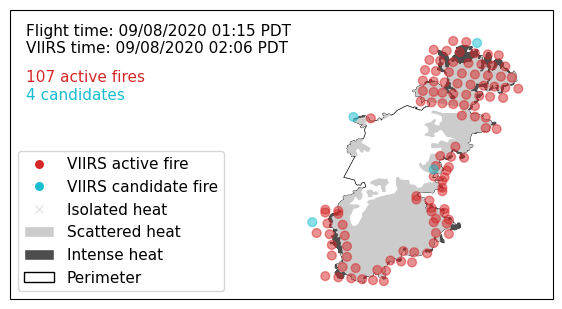

In [31]:
for d, file_date in zip(matches, file_dates):

    subset = dets[np.abs(dets.datetime - d) < dt.timedelta(hours=2)]
    files = os.listdir('/projects/shared-buckets/coffield/nirops/raw/Bobcat/')
    files = [f for f in files if f[:8] == str(file_date)]
    files = [f for f in files if f[-3:] == 'shp']

    newcolors = [mpl.colormaps['tab10'](c) for c in [9,9,9,9,9,9,9,3,3,3]] #just old vs new dets
    newcmp = ListedColormap(newcolors)

    crs = ccrs.PlateCarree()
    crs_proj4 = crs.proj4_init

    fig, ax = plt.subplots(1,1, figsize=(7,6), subplot_kw={"projection": crs})
    ax.set_extent([extent.minx, extent.maxx-0.14, extent.miny+0.05, extent.maxy-0.18])

    ax.scatter(subset['longitude'], subset['latitude'], c=newcmp(subset['fire_mask'].astype(int)), s=40, zorder=100, alpha=0.5, transform=ccrs.Geodetic())

    perims = [f for f in files if 'Perimeter' in f] #sometimes multiple pieces
    for perim in perims:
        perim = gpd.read_file(f'/projects/shared-buckets/coffield/nirops/raw/Bobcat/{perim}')
        perim_reproj = perim.to_crs(crs_proj4)
        ax.add_geometries(perim_reproj.geometry, crs=crs, facecolor='none', edgecolor='k', linewidth=0.5)

    intens = [f for f in files if 'Intense' in f]
    for inten in intens:
        inten = gpd.read_file(f'/projects/shared-buckets/coffield/nirops/raw/Bobcat/{inten}')
        inten_reproj = inten.to_crs(crs_proj4)
        ax.add_geometries(inten_reproj.geometry, crs=crs, facecolor='0.3')

    isolas = [f for f in files if 'Isolated' in f]
    for isola in isolas:
        isola = gpd.read_file(f'/projects/shared-buckets/coffield/nirops/raw/Bobcat/{isola}')
        ax.scatter(isola.geometry.x, isola.geometry.y, transform=ccrs.Geodetic(), color='0.9', s=10, marker='x', label='Isolated Heat')

    scatts = [f for f in files if 'Scattered' in f]
    for scatt in scatts:
        scatt = gpd.read_file(f'/projects/shared-buckets/coffield/nirops/raw/Bobcat/{scatt}')
        scatt_reproj = scatt.to_crs(crs_proj4)
        ax.add_geometries(scatt_reproj.geometry, crs=crs, facecolor='0.8')

    #legend
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch

    legend_elements = [Line2D([0], [0], marker='.', color='w', label='VIIRS active fire', markerfacecolor=newcmp(7), markersize=15),
                       Line2D([0], [0], marker='.', color='w', label='VIIRS candidate fire', markerfacecolor=newcmp(0), markersize=15),
                       Line2D([0], [0], marker='x', color='0.9', label='Isolated heat', markersize=6, linestyle=''),
                       Patch(facecolor='0.8', edgecolor='w', label='Scattered heat'),
                       Patch(facecolor='0.3', edgecolor='w', label='Intense heat'),
                       Patch(facecolor='none', edgecolor='k', label='Perimeter'),
                      ]
    ax.legend(handles=legend_elements, loc='lower left', fontsize=11)

    flight_time = (d - dt.timedelta(hours=7)).strftime("%m/%d/%Y %H:%M")
    #viirs_time = subset.loc[pd.to_datetime(str(t)).strftime("%m/%d/%Y %H:%M") for t in np.unique(subset.datetime)]
    viirs_time = (subset.datetime.iloc[0] - dt.timedelta(hours=7)).strftime("%m/%d/%Y %H:%M")
    ax.annotate(f'Flight time: {flight_time} PDT\nVIIRS time: {viirs_time} PDT', xy=(0.03, 0.85), size=11, xycoords=ax.transAxes)
    
    n_known = len(subset[subset.fire_mask>6])
    n_candi = len(subset[subset.fire_mask<7])
    ax.annotate(f'{n_known} active fires', xy=(0.03, 0.75), color=newcmp(7), size=11, xycoords=ax.transAxes)
    ax.annotate(f'{n_candi} candidates', xy=(0.03, 0.69), color=newcmp(0), size=11, xycoords=ax.transAxes)

    plt.savefig(f'/projects/my-public-bucket/figures/nirops_bobcat_{file_date}', bbox_inches='tight', dpi=125)

<h3>Dolan

In [32]:
extent = fires.loc[fires.name=='DOLAN', 'geometry'].bounds
extent

,minx,miny,maxx,maxy
19,-121.707253,35.939871,-121.237981,36.226902


In [33]:
dets = dets_all[dets_all.Incid_Name=='DOLAN']
dets.head()

,longitude,latitude,fire_mask,daynight,confidence,acq_date,acq_time,j,i750,j750,frp_old,frp,dist_m13b,fireid,Incid_Name,datetime
336966,-121.266600,35.969788,5,D,x,8/15/20,2112,2542,2527,1271,NaN,3.324087,0.651990,F11716,DOLAN,2020-08-15 21:12:00
336967,-121.271484,35.969177,5,D,x,8/15/20,2112,2543,2527,1271,NaN,3.324087,0.651990,F11716,DOLAN,2020-08-15 21:12:00
336968,-121.269530,35.969850,5,D,x,8/15/20,2112,2541,2528,1270,NaN,6.296162,0.654155,F11716,DOLAN,2020-08-15 21:12:00
336969,-121.274414,35.969300,5,D,x,8/15/20,2112,2542,2528,1271,NaN,6.230118,0.657330,F11716,DOLAN,2020-08-15 21:12:00
336970,-121.309570,35.972046,5,D,x,8/15/20,2112,2549,2529,1274,NaN,2.333557,0.685211,F11716,DOLAN,2020-08-15 21:12:00


In [34]:
#nirops - all (processed Tina)
processed = gpd.read_file('/projects/shared-buckets/coffield/nirops/processed/Dolan_2020_perim.shp')[['prodDate','flightDate','flightTime','flight_tz','flight_UTC']]
processed.flight_UTC = pd.to_datetime(processed.flight_UTC)
processed

,prodDate,flightDate,flightTime,flight_tz,flight_UTC
0,20200824.0,20200824.0,340.0,UTC,2020-08-24 03:40:00
1,20200826.0,20200826.0,430.0,UTC,2020-08-26 04:30:00
2,20200829.0,20200829.0,805.0,UTC,2020-08-29 08:05:00
3,20200831.0,20200831.0,100.0,UTC,2020-08-31 01:00:00
4,20200901.0,20200901.0,230.0,UTC,2020-09-01 02:30:00
5,20200902.0,20200902.0,230.0,UTC,2020-09-02 02:30:00
6,20200903.0,20200903.0,230.0,UTC,2020-09-03 02:30:00
7,20200904.0,20200904.0,645.0,UTC,2020-09-04 06:45:00
8,20200905.0,20200905.0,630.0,UTC,2020-09-05 06:30:00
9,20200906.0,20200906.0,540.0,UTC,2020-09-06 05:40:00


In [35]:
#loop through nirops and count how many matches to VIIRS within 2 hours
matches = []
file_dates = []

for i in processed.index:
    datetime = processed.loc[i, 'flight_UTC']
    subset = dets[np.abs(dets.datetime - datetime) < dt.timedelta(hours=2)]
    
    if len(subset)>0:
        print(f'match at flight time: {datetime} UTC\n VIIRS time: {np.unique(subset.datetime)} UTC\n')
        matches.append(datetime)
        file_dates.append(int(processed.loc[i, 'flightDate']))

match at flight time: 2020-08-29 08:05:00 UTC
 VIIRS time: ['2020-08-29T08:48:00.000000000'] UTC

match at flight time: 2020-09-08 09:00:00 UTC
 VIIRS time: ['2020-09-08T09:06:00.000000000' '2020-09-08T10:42:00.000000000'] UTC

match at flight time: 2020-09-09 08:15:00 UTC
 VIIRS time: ['2020-09-09T08:42:00.000000000'] UTC

match at flight time: 2020-09-10 09:00:00 UTC
 VIIRS time: ['2020-09-10T10:06:00.000000000'] UTC



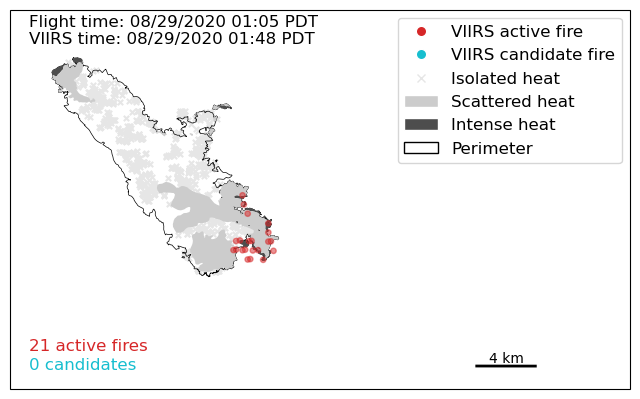

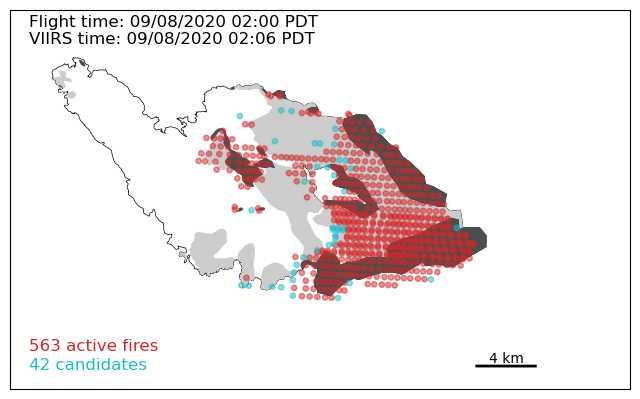

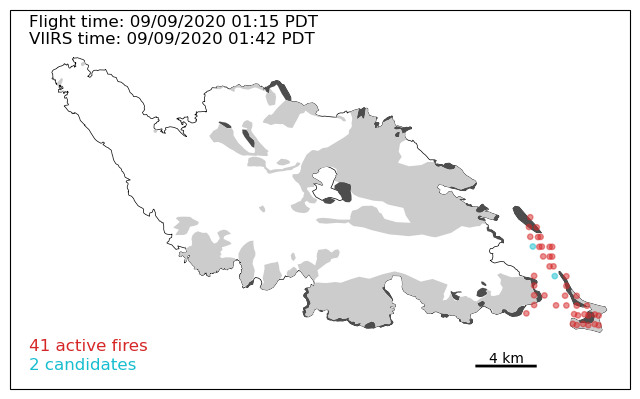

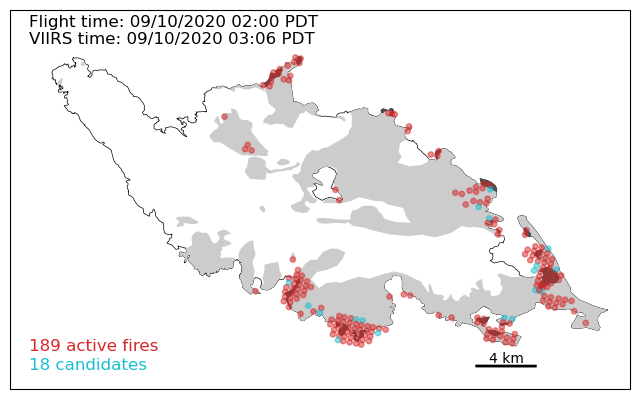

In [39]:
for d, file_date in zip(matches, file_dates):

    subset = dets[np.abs(dets.datetime - d) < dt.timedelta(hours=1.5)] #CHANGED THRESHOLD
    files = os.listdir('/projects/shared-buckets/coffield/nirops/raw/Dolan/')
    files = [f for f in files if f[:8] == str(file_date)]
    files = [f for f in files if f[-3:] == 'shp']

    newcolors = [mpl.colormaps['tab10'](c) for c in [9,9,9,9,9,9,9,3,3,3]] #just old vs new dets
    newcmp = ListedColormap(newcolors)

    crs = ccrs.PlateCarree()
    crs_proj4 = crs.proj4_init

    fig, ax = plt.subplots(1,1, figsize=(8,8), subplot_kw={"projection": crs})
    ax.set_extent([extent.minx, extent.maxx, extent.miny, extent.maxy])

    ax.scatter(subset['longitude'], subset['latitude'], c=newcmp(subset['fire_mask'].astype(int)), s=15, zorder=100, alpha=0.5, transform=ccrs.Geodetic())
    n_known = len(subset[subset.fire_mask>6])
    n_candi = len(subset[subset.fire_mask<7])
    
    perims = [f for f in files if 'Perimeter' in f] #sometimes multiple pieces
    for perim in perims:
        perim = gpd.read_file(f'/projects/shared-buckets/coffield/nirops/raw/Dolan/{perim}')
        perim_reproj = perim.to_crs(crs_proj4)
        ax.add_geometries(perim_reproj.geometry, crs=crs, facecolor='none', edgecolor='k', linewidth=0.5)

    intens = [f for f in files if 'Intense' in f]
    for inten in intens:
        inten = gpd.read_file(f'/projects/shared-buckets/coffield/nirops/raw/Dolan/{inten}')
        inten_reproj = inten.to_crs(crs_proj4)
        ax.add_geometries(inten_reproj.geometry, crs=crs, facecolor='0.3')

    isolas = [f for f in files if 'Isolated' in f]
    for isola in isolas:
        isola = gpd.read_file(f'/projects/shared-buckets/coffield/nirops/raw/Dolan/{isola}')
        ax.scatter(isola.geometry.x, isola.geometry.y, transform=ccrs.Geodetic(), color='0.9', s=15, marker='x', label='Isolated Heat')

    scatts = [f for f in files if 'Scattered' in f]
    for scatt in scatts:
        scatt = gpd.read_file(f'/projects/shared-buckets/coffield/nirops/raw/Dolan/{scatt}')
        scatt_reproj = scatt.to_crs(crs_proj4)
        ax.add_geometries(scatt_reproj.geometry, crs=crs, facecolor='0.8')

    #legend
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch

    legend_elements = [Line2D([0], [0], marker='.', color='w', label='VIIRS active fire', markerfacecolor=newcmp(7), markersize=15),
                       Line2D([0], [0], marker='.', color='w', label='VIIRS candidate fire', markerfacecolor=newcmp(0), markersize=15),
                       Line2D([0], [0], marker='x', color='0.9', label='Isolated heat', markersize=6, linestyle=''),
                       Patch(facecolor='0.8', edgecolor='w', label='Scattered heat'),
                       Patch(facecolor='0.3', edgecolor='w', label='Intense heat'),
                       Patch(facecolor='none', edgecolor='k', label='Perimeter'),
                      ]
    if file_date==20200829: ax.legend(handles=legend_elements, loc='upper right', fontsize=12)
    scale_bar(ax, 4, location=(0.8, 0.06), linewidth=2)
    
    flight_time = (d - dt.timedelta(hours=7)).strftime("%m/%d/%Y %H:%M")
    #viirs_time = subset.loc[pd.to_datetime(str(t)).strftime("%m/%d/%Y %H:%M") for t in np.unique(subset.datetime)]
    viirs_time = (subset.datetime.iloc[0] - dt.timedelta(hours=7)).strftime("%m/%d/%Y %H:%M")
    ax.annotate(f'Flight time: {flight_time} PDT\nVIIRS time: {viirs_time} PDT', xy=(0.03, 0.91), size=12, xycoords=ax.transAxes)
    
    ax.annotate(f'{n_known} active fires', xy=(0.03, 0.1), color=newcmp(7), size=12, xycoords=ax.transAxes)
    ax.annotate(f'{n_candi} candidates', xy=(0.03, 0.05), color=newcmp(0), size=12, xycoords=ax.transAxes)
    #ax.set_title('Dolan fire')
    plt.savefig(f'/projects/my-public-bucket/figures/nirops_dolan_{file_date}', bbox_inches='tight', dpi=125)